# Getting an overview
- loading the data files
- shape of tables
- columns

In [2]:
import pandas as pd

path = r"C:\Users\ThinkPad\Desktop\Mastermind\Inside_Airbnb_Berlin\Data\listings.csv"
listings = pd.read_csv(path)
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 14274 entries, 0 to 14273
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            14274 non-null  int64  
 1   listing_url                                   14274 non-null  str    
 2   scrape_id                                     14274 non-null  int64  
 3   last_scraped                                  14274 non-null  str    
 4   source                                        14274 non-null  str    
 5   name                                          14274 non-null  str    
 6   description                                   13712 non-null  str    
 7   neighborhood_overview                         6474 non-null   str    
 8   picture_url                                   14274 non-null  str    
 9   host_id                                       14274 non-null  int64  
 1

In [ ]:
# getting the table headers as a text file
with open("../Data/listings_headers.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(listings.columns))

# Ideas what to plot from table headers
- the lower the number for **host_since** the higher the xx price?
- the lower the host_response_time the xxxxxx
- what does **host_is_superhost, host_verifications, host_has_profile_pic, host_identity_verified** acutally benefit the host?
- Spread of **minimum_minimum_nights, maximum_minimum_nights, minimum_maximum_nights, maximum_maximum_nights**
- Make correlation matrix for all numeric columns
- Via **avability_30, .._60, ..._90, ..._365**: How long before the acutal traval do people book? And when whas the data scapped? -> **calendar_last_scraped**
- Many recent reviews -> many recent bookings and vice versa for long ago reviews
- When did most new airbnbs enter the marked?
- revenue!
- how does instant bookable influence the avabililty?
- reviews per month
- big business behind the airbnb? **calculated_host_listings_count**
- What should be in the name or description to make it bookable




# Questions needed to be answered:
- How many nunique (and which) for **property_type**? -> 65
- How many nunique for **room_type**? -> 4

In [4]:

# getting the table headers & nunique vlaues as a text file
nu = listings.nunique()
with open("../Data/listing_headers_nunique.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(f"{col}: {count}" for col, count in nu.items()))

# Correlation matrix for all columns containing numbers

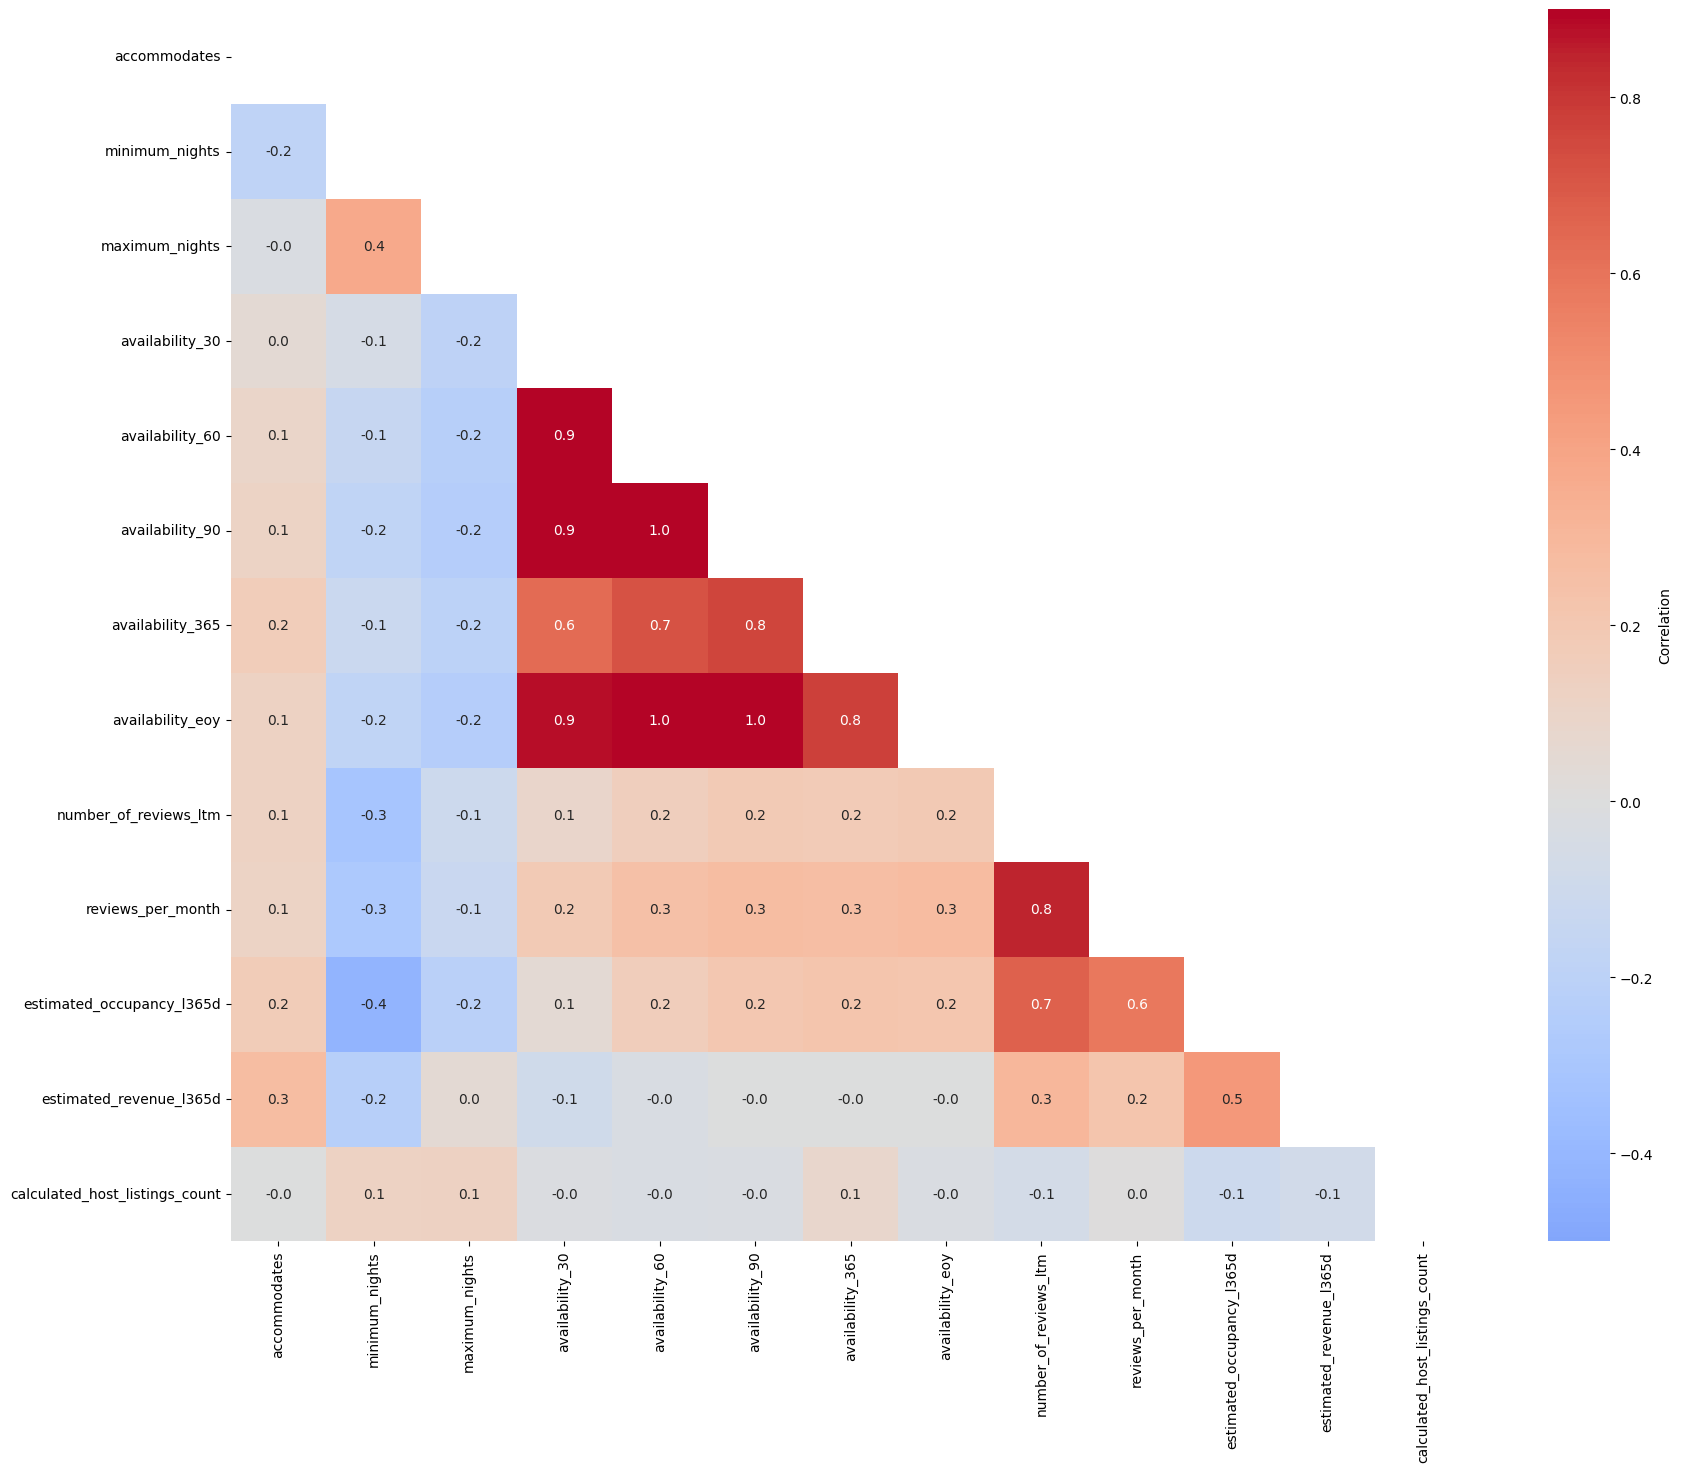

In [25]:
# only one dicimal as many numbers
# remove id, scrape_id, host_id, calendar_updated, as either meaningles or empty columns

import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
os.makedirs("../Data/SelmasPlots", exist_ok=True)

cols_to_drop = [
    "id", "scrape_id", "host_id", "calendar_updated",
    "host_total_listings_count", "host_listings_count",
    "latitude", "longitude",
    "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
    "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    "number_of_reviews", "number_of_reviews_l30d", "number_of_reviews_ly",
    "review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness",
    "review_scores_checkin", "review_scores_communication",
    "review_scores_location", "review_scores_value",
    "bathrooms", "bedrooms", "beds",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms", "availability_30", "availability_60", "availability_90", "availability_eoy"
]

# Custom order: stays/size → availability → reviews → host/revenue
ordered_cols = [
    "accommodates", "minimum_nights", "maximum_nights",
    "availability_365",
    "number_of_reviews_ltm", "reviews_per_month",
    "estimated_occupancy_l365d", "estimated_revenue_l365d",
    "calculated_host_listings_count",
]

# Mask the diagonal (where value = 1.0)
mask = np.eye(len(corr), dtype=bool)

# Show only LOWER triangle (hides upper + diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr, annot=True, fmt=".1f", cmap="coolwarm", center=0,
    mask=mask, vmin=-0.5, vmax=0.9,
    cbar_kws={"label": "Correlation"}
)
plt.savefig("../Data/SelmasPlots/correlation_matrix_everynumberedcolumn.png", bbox_inches="tight", dpi=150)
plt.show()

# Ideas from Claude

## Plot mapping (each topic = a different plot type):

* Map (boroughs by listing count / price) → Choropleth
* Commercial hosts → Pareto chart (Bar + Line overlaid ✓)
* Superhost rating → Violin plot (instead of boxplot — more sophisticated)
* Host tenure → Histogram with KDE line overlay
* Prices throughout the year → Line chart + trendline / moving average
* Weekdays → Ridge plot (stacked density curves)
* Heatmap day × month → stays a heatmap
* Price ↔ Rating → Scatter with regression line (sns.regplot or lmplot) ✓
* >90 days violations → ECDF plot with vertical line at 90

## Where clustering makes sense:

K-Means on listings: features like price, accommodates, review_scores_rating, availability_365, calculated_host_listings_count → discover groups such as "cheap private rooms", "luxury apartments", "commercial tourist flats"
Visualization: PCA reduced to 2D + scatter colored by cluster, or plot directly on the map

## Sophisticated overlay plots:

Scatter + regression curve (price ↔ rating)
Bar + Line (Pareto: hosts × cumulative revenue %)
Map + cluster colors (listings as points, colored by cluster)
Histogram + KDE (host tenure)
Boxplot + strip plot (superhost vs. non-superhost, with individual points overlaid)

## Recommendation — diverse plot gallery:

Choropleth (map)
Pareto (bar + line)
Scatter + regression
Heatmap
Violin
Cluster scatter (PCA)
ECDF

= 7 different plot types, one clustering, one regression, two overlaid plot combinations. ✓

# Commercial host -> Pareto chart

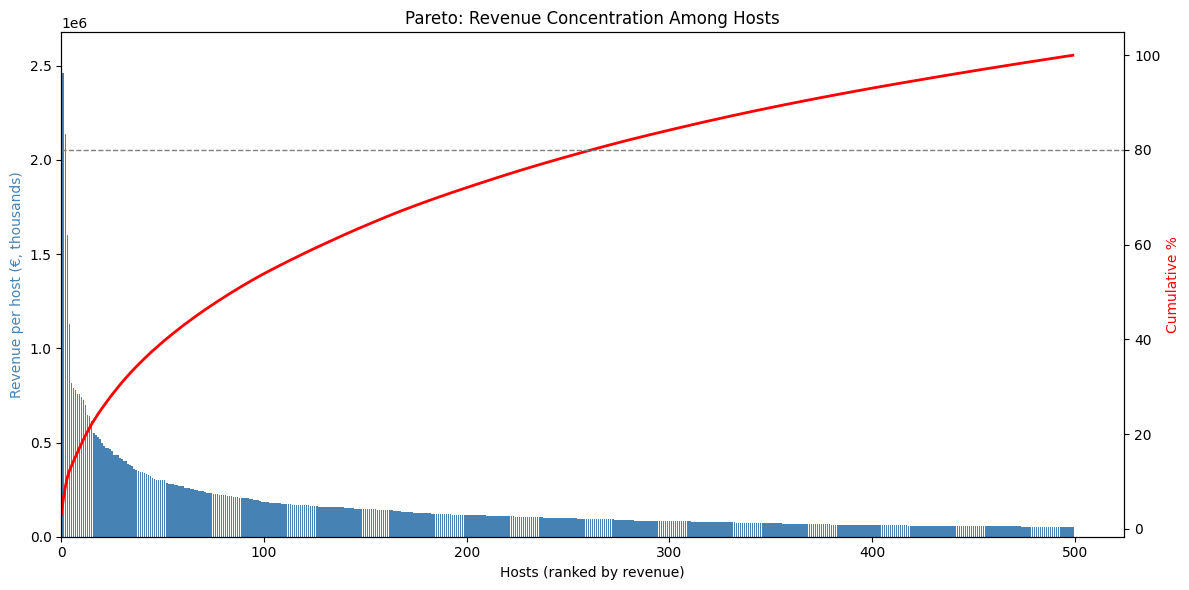

In [32]:
import matplotlib.pyplot as plt
import os

os.makedirs("../Data/SelmasPlots", exist_ok=True)

# 1. Get revenue per host, sorted descending
host_revenue = (
    listings.groupby("host_id")["estimated_revenue_l365d"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(drop=True)
)


top_n = 500
host_revenue = host_revenue.iloc[:top_n]
cumulative_pct = cumulative_pct.iloc[:top_n]


# 2. Cumulative percentage
cumulative_pct = host_revenue.cumsum() / host_revenue.sum() * 100

# 3. Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(range(len(host_revenue)), host_revenue, color="steelblue")
ax1.set_xlabel("Hosts (ranked by revenue)")
ax1.set_ylabel("Revenue per host (€, thousands)", color="steelblue")
# ax1.set_yscale("log")  # log scale to see the long tail
ax1.set_xlim(left=0)

ax2 = ax1.twinx()
ax2.plot(range(len(cumulative_pct)), cumulative_pct, color="red", linewidth=2)
ax2.set_ylabel("Cumulative %", color="red")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)

plt.title("Pareto: Revenue Concentration Among Hosts")
plt.tight_layout()
plt.savefig("../Data/SelmasPlots/pareto_host_revenue.png", bbox_inches="tight", dpi=150)
plt.show()

 Ungefähr die Top 1.000 von ~9.500 Hosts (also nur ~10%) erwirtschaften 80% des gesamten Airbnb-Umsatzes in Berlin — das ist eine extreme Konzentration und ein klares Zeichen für einen stark kommerzialisierten Markt. Die restlichen 90% der Hosts teilen sich nur 20% des Umsatzes auf, was bedeutet, dass die meisten Vermieter eher Gelegenheits-Hosts sind, während eine kleine Gruppe von Profi-/Mehrfach-Vermietern den Markt dominiert.

#  Superhost rating → Violin plot


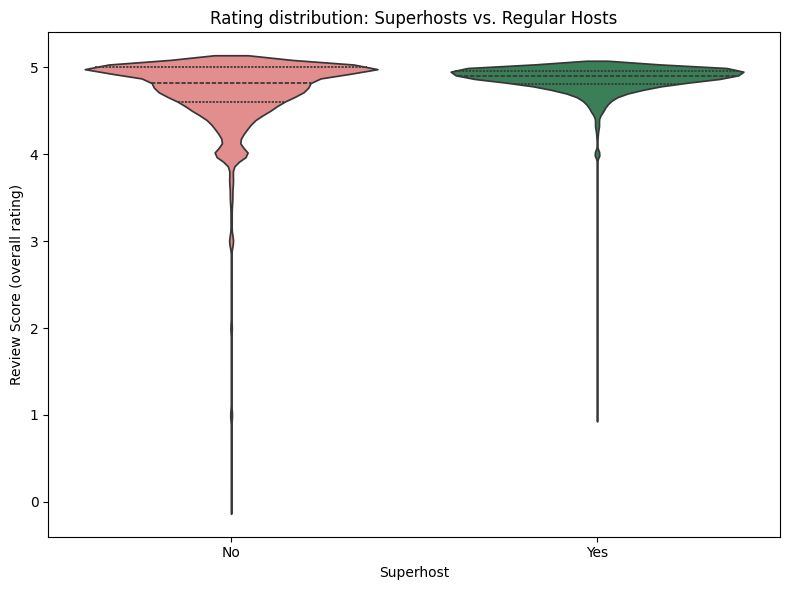

In [33]:


os.makedirs("../Data/SelmasPlots", exist_ok=True)

# Filter out missing values
data = listings.dropna(subset=["host_is_superhost", "review_scores_rating"])

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=data,
    x="host_is_superhost",
    y="review_scores_rating",
    hue="host_is_superhost",
    palette={"t": "seagreen", "f": "lightcoral"},
    inner="quartile",   # shows median + quartiles inside the violin
    legend=False,
)
plt.xlabel("Superhost")
plt.ylabel("Review Score (overall rating)")
plt.title("Rating distribution: Superhosts vs. Regular Hosts")
plt.xticks([0, 1], ["No", "Yes"])
plt.tight_layout()
plt.savefig("../Data/SelmasPlots/violin_superhost_rating.png", bbox_inches="tight", dpi=150)
plt.show()